In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform, euclidean

In this tutorial, we illustrate how to solve a Maximally Weighted Independent Set (MWIS) problem using an ensemble of Rydberg atoms in analog mode. This requires a feature that is not currently available on Ruby machine, local adressability, so we are going to have to pick a device ta allow us to manipulate atoms as if it was installed. We are curretnly finalizing a first prototype on our computers in Pasqal. If that kind of problems (MWIS) is of interest to you to be run on Ruby do not hesitate to notify it to GENCI or TGCC personnal.

MWIS arise in many applications, including resource allocation, scheduling and staffing problems, error-correcting coding, complex system analysis and optimization, logistics and transportation, communication networks…

In the MWIS problem, we consider an undirected graph with nodes and edges where each node is associated with a positive weight. The problem is to find a maximum weighted independent set, i.e., select a set of nodes in graph where:

-there is no edge between any pair of selected nodes.

-the sum of the weights of the nodes for this set is maximised.

In [95]:
# Note: don t hesitate to play with the weights (diagonal terms) to see what changes in the final distribution!

Q = np.array(
    [
        [0, 1, 1, 1],
        [1, 2, 0, 0],
        [1, 0, 2, 1],
        [1, 0, 1, 0],
    ]
)

Mathematically, a graph is represented by its adjacency matrix(external) 
, a symmetric matrix N*N
, with N
 the number of nodes in the graph.

 The optimization problem associated with the MWIS is to find the bitstring $z=(z_1, \dots, z_N) \in \{0, 1 \}^N$
 that maximizes the quantity $$f(z) = \sum_i Q_{ii} z_i$$

 
under the constraint, for $i\ne j$
, $$Q_{ij}z_i + Q_{ij}z_j \le 1$$

For the above graph, the optimal solution for the MWIS problem is 0110.

This is the same as  when solving a QUBO, except that we want here to maximize it instead of minimizing it in the case of the QUBO.

Let’s recall that Pulser enables you to program the Ising Hamiltonian  $$\frac{H_Q}{\hbar}(t) = \sum_{k=1}^N \left (\frac{\Omega(t)}{2} e^{-i\phi(t)} |g\rangle\langle r|_k + \frac{\Omega(t)}{2} e^{i\phi(t)} |r\rangle\langle g|_k - \delta(t) |r\rangle\langle r|_k + \sum_{j<k}\frac{C_6}{\hbar R_{kj}^6} \hat{n}_k \hat{n}_j \right)$$

Once again the key idea is to encode the off-diagonal terms by using the Rydberg interaction between atoms:$$\left[\frac{C_6}{\hbar R_{kj}^6}\right]_{1\leq k, j \leq N}\leftrightarrow Q_{off-diagonal}$$

Once again we are happy because the off diagonal terms are non negative.

The second idea is to encode the diagonal terms of Q 
 by using the weights of the Detuning Map (what is that? you might say)
 $\epsilon_k \leftrightarrow Q_{kk}$ for $1\le k\le N$
.

The DetuningMap consists of a set of weights on specific sites that dictate the proportion of detuning applied by the DMM each site receives. See it as the relative strenght with which you apply the $\delta$ channel. It is equivalent to adding $-\hbar\sum_{k}\epsilon_{k}\delta_{DMM}(t)|r\rangle\langle r|_k$ to the ising hamiltonian.

Notice here the $\delta$ depends on k contrary to the first formula.

For more precisions on the detuning map check https://docs.pasqal.com/pulser/tutorials/dmm/

In [96]:

device = pulser.MockDevice
device.print_specs()

-------------------------
MockDevice Specifications
-------------------------
A virtual device for unconstrained prototyping.

Register parameters:
 - Dimensions: 3D
 - Minimum distance between neighbouring atoms: 0.0 μm

Layout parameters:
 - Requires layout: No
 - Minimal number of traps: 1
 - Minimum layout filling fraction: 0.0
 - Maximum layout filling fraction: 0.5

Device parameters:
 - Rydberg level: 70
 - Ising interaction coefficient: 5420158.53
 - XY interaction coefficient: 3700.0
 - Channels can be reused: Yes
 - Supported bases: ground-rydberg, digital, XY
 - Supported states: u, d, r, g, h
 - SLM Mask: Yes

Channels:
 - 'rydberg_global': Rydberg(addressing='Global', max_abs_detuning=None, max_amp=None, min_retarget_interval=None, fixed_retarget_t=None, max_targets=None, clock_period=1, min_duration=1, max_duration=None, min_avg_amp=0, mod_bandwidth=None, custom_phase_jump_time=None, eom_config=None, propagation_dir=None)
 - 'rydberg_local': Rydberg(addressing='Local', ma

To implement the Hamiltonian 
, we need a Device containing a Rydberg.Global channel and a DMM object. pulser.DigitalAnalogDevice and pulser.MockDevice are examples of Devices that contain these two channels. For this specific use case, let’s use pulser.MockDevice to not be limited in terms of duration.

Let’s attempt a simple minimization procedure to find the optimal positions of the atoms in the Register that replicate best the off-diagonal terms of Q.


This optimizer approach will not work for all the graphs. You can change the optimizer to improve it but it is a simple heuristic and should not be considered as an universal encoder.

In [97]:
def evaluate_mapping(
    new_coords: np.ndarray, Q: np.ndarray, device: pulser.devices.Device
):
    """Cost function to minimize. Ideally, the pairwise distances are conserved."""
    new_coords = np.reshape(new_coords, (len(Q), 2))
    # computing the matrix of the distances between all coordinate pairs
    new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6) / 4
    return np.linalg.norm(new_Q - Q)

In [98]:
costs = []
np.random.seed(0)
x0 = np.random.random(len(Q) * 2)
res = minimize(
    evaluate_mapping,
    x0,
    args=(~np.eye(Q.shape[0], dtype=bool) * Q, device),
    method="Nelder-Mead",
    tol=1e-6,
    options={"maxiter": 200000, "maxfev": None},
)
coords = np.reshape(res.x, (len(Q), 2))

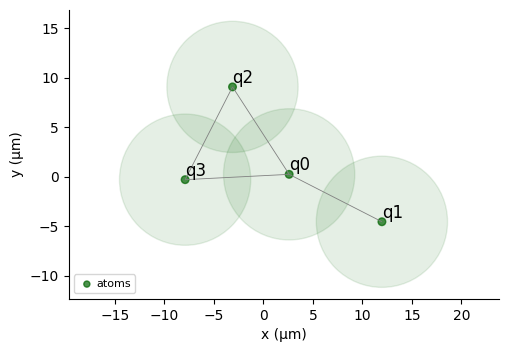

In [99]:
qubits = {f"q{i}": coord for (i, coord) in enumerate(coords)}
reg = pulser.Register(qubits)
reg.draw(
    blockade_radius=device.rydberg_blockade_radius(1.0),
    draw_graph=True,
    draw_half_radius=True,
)

In [100]:
#Let’s check that this register respects the device’s constraints by initializing the Sequence:


sequence = pulser.Sequence(reg, device)

The first channel needed to implement the Ising Hamiltonian 
 is the Rydberg.Global channel. Let’s declare this channel in the Sequence:

In [101]:
sequence.declare_channel("rydberg_global", "rydberg_global")

for the moment the hamiltonian of the sequence is $\sum_{k=1}^N \left(\frac{\Omega(t)}{2} e^{-i\phi(t)} |g\rangle \langle r|_k + \frac{\Omega(t)}{2} e^{i\phi(t)} |r\rangle\langle g|_k - \delta(t) |r\rangle\langle r|_k(t) + \sum_{j<k}\frac{C_6}{\hbar R_{kj}^6} \hat{n}_k \hat{n}_j \right)$


The second channel needed to implement the Weighted Analog Ising Hamiltonian 
 is the DMM channel, that adds the terms $-\sum_{1\le k\le N}\mathbf{\epsilon_k\delta_{DMM}(t)} |r\rangle\langle r|_k$ 
 to the Ising Hamiltonian.

When configuring the DMM channel, we need to provide it a DetuningMap, which assigns to each atom in the Register a weight $\left[\epsilon_k\right]_{1\le k \le N}$
.

Using the diagonal of the matrix :math:`Q`, we decide that:

-the atoms that have the highest weight will not experience any additionnal detuning $\delta_{DMM}$
 (we want to favor the solution for the maximal weights).

-each of the other atoms will experience an additionnal detuning, that is proportional to the difference between the highest weight and their weight.

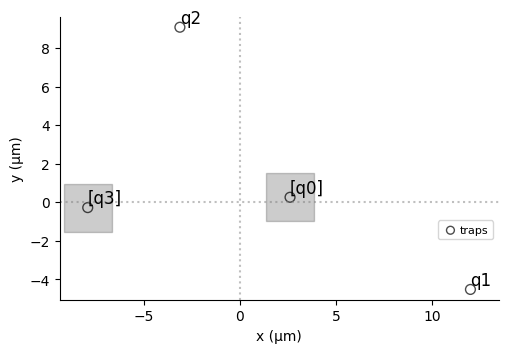

In [102]:
node_weights = np.diag(Q)
norm_node_weights = node_weights / np.max(node_weights)
det_map_weights = 1 - norm_node_weights
det_map = reg.define_detuning_map(
    {f"q{i}": det_map_weights[i] for i in range(len(det_map_weights))}
)
det_map.draw(labels=reg.qubit_ids)

In [103]:
sequence.config_detuning_map(det_map, "dmm_0")

Note: If we wanted to favor the lowest diagonal terms instead of the highest (as in the case of a QUBO with diagonal terms), we would have decided that:

-the atoms that have the lowest weight will not experience any additionnal detuning 
.

-each of the other atoms will experience an additionnal detuning, that is proportional to the difference between their weight and the lowest weight.

In [104]:
# Compute the maximum interaction between two non-connected atoms
distance_non_connected = []
for i in range(1, Q.shape[0]):
    for j in range(i - 1):
        if Q[i, j] == 0:
            distance_non_connected.append(
                euclidean(reg.qubits[f"q{i}"], reg.qubits[f"q{j}"])
            )
Omega = device.interaction_coeff / np.min(distance_non_connected) ** 6 * 10
delta_0 = -Omega  # just has to be negative
delta_f = -delta_0  # just has to be positive
T = 40000  # time in ns, we choose a time long enough to ensure the propagation of information in the system

We are still doing an adiabatic evolution as in the last tutorials. The only difference here is that to favor the final ground-state to be in an optimal solution of the MWIS, we will add a penalty detuning to the qubits associated with the lowest weights by adding a constant local detuning $\delta_{DMM}(t) = - \delta_f$
.

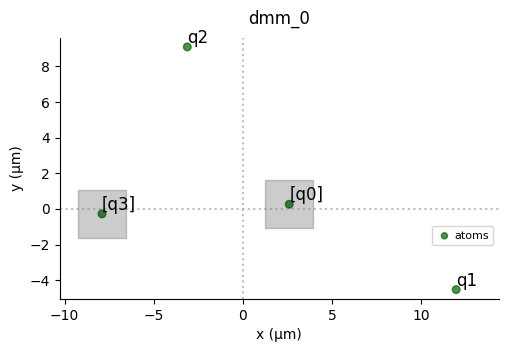

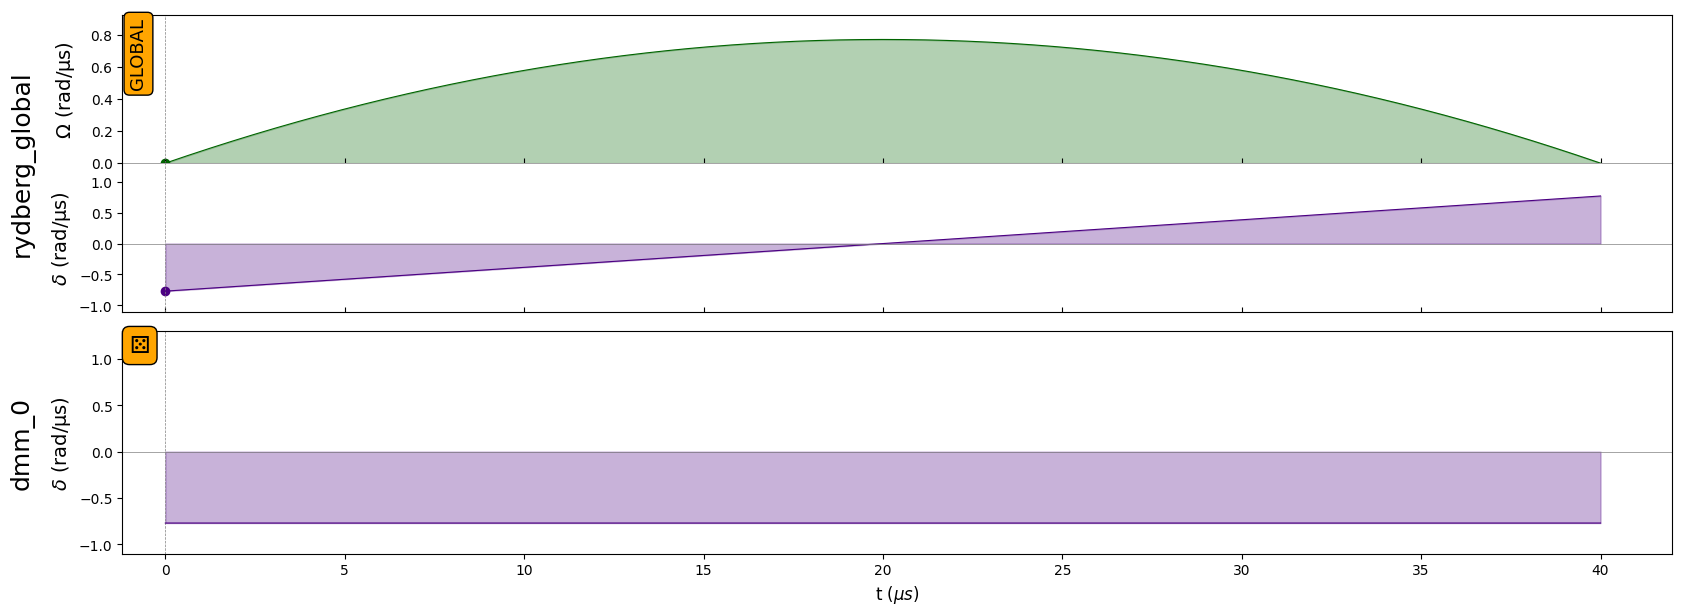

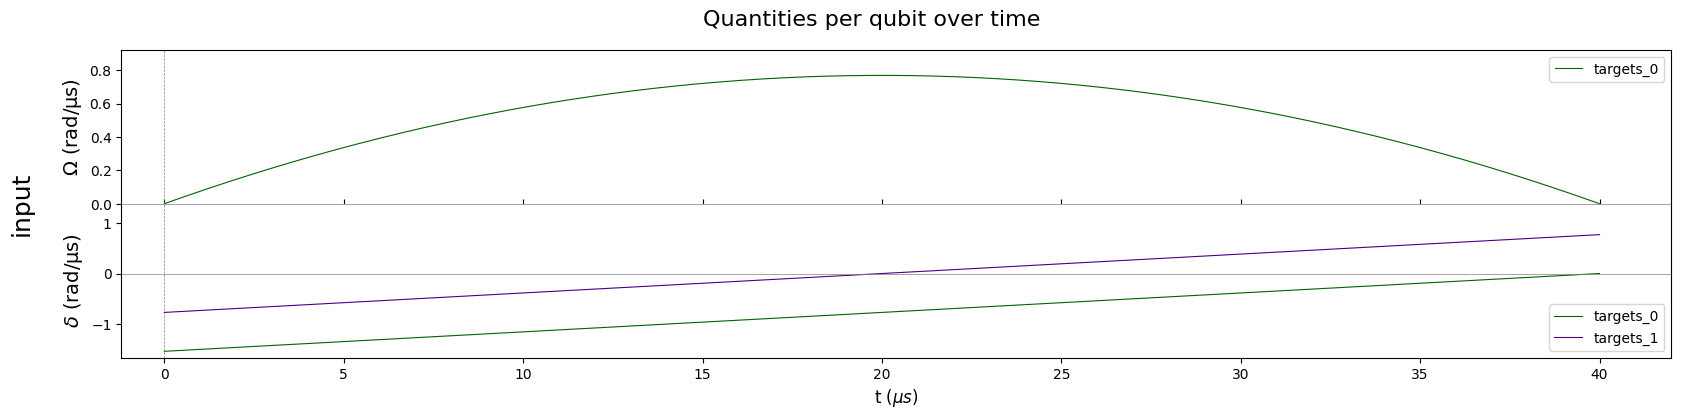

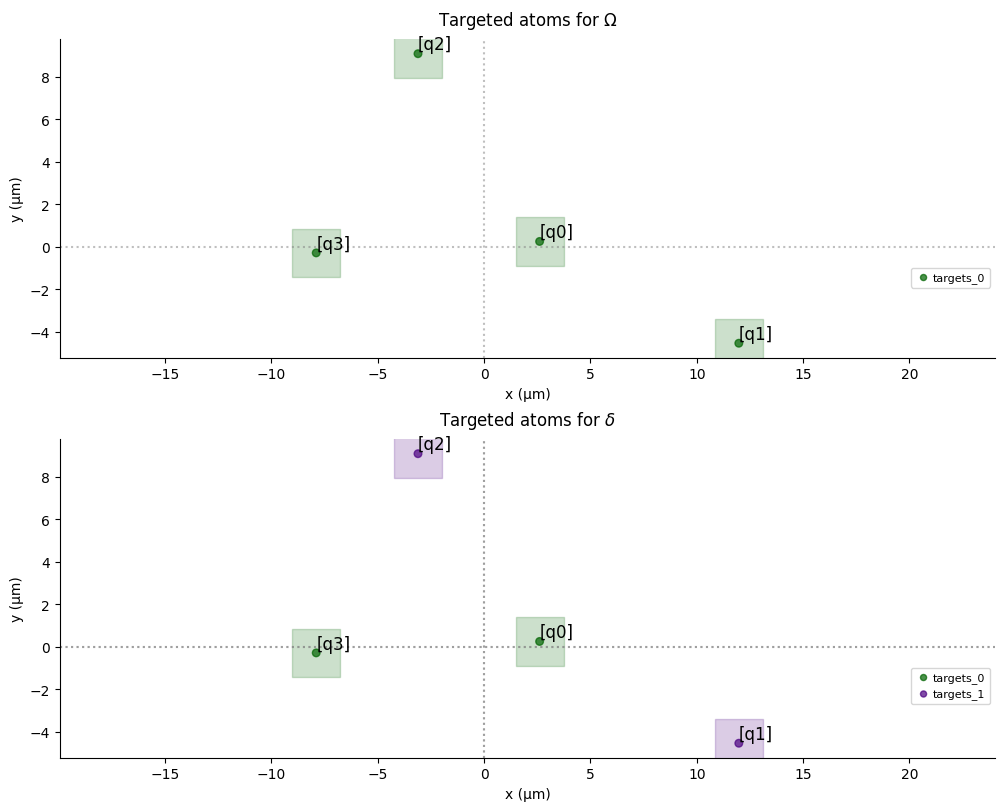

In [105]:
# Adiabatic pulse added to the Rydberg Global
adiabatic_pulse = pulser.Pulse(
    pulser.InterpolatedWaveform(T, [1e-9, Omega, 1e-9]),
    pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0,
)
sequence.add(adiabatic_pulse, "rydberg_global")
# Constant pulse added to the DMM
sequence.add_dmm_detuning(pulser.ConstantWaveform(T, -delta_f), "dmm_0")
sequence.draw(
    draw_detuning_maps=True,
    draw_qubit_det=True,
    draw_qubit_amp=True,
)  # ,fig_name= "no_final_amplitude.pdf"

In [106]:
simul = pulser_simulation.QutipBackendV2(sequence)
results = simul.run()
count_dict = results.final_bitstrings

In [107]:
def plot_distribution(C):
    C = dict(sorted(C.items(), key=lambda item: item[1], reverse=True))
    indexes = ["0110"]  # best solution
    color_dict = {key: "r" if key in indexes else "g" for key in C}
    plt.figure(figsize=(12, 6))
    plt.xlabel("bitstrings")
    plt.ylabel("counts")
    plt.bar(C.keys(), C.values(), width=0.5, color=color_dict.values())
    plt.xticks(rotation="vertical")
    plt.show()

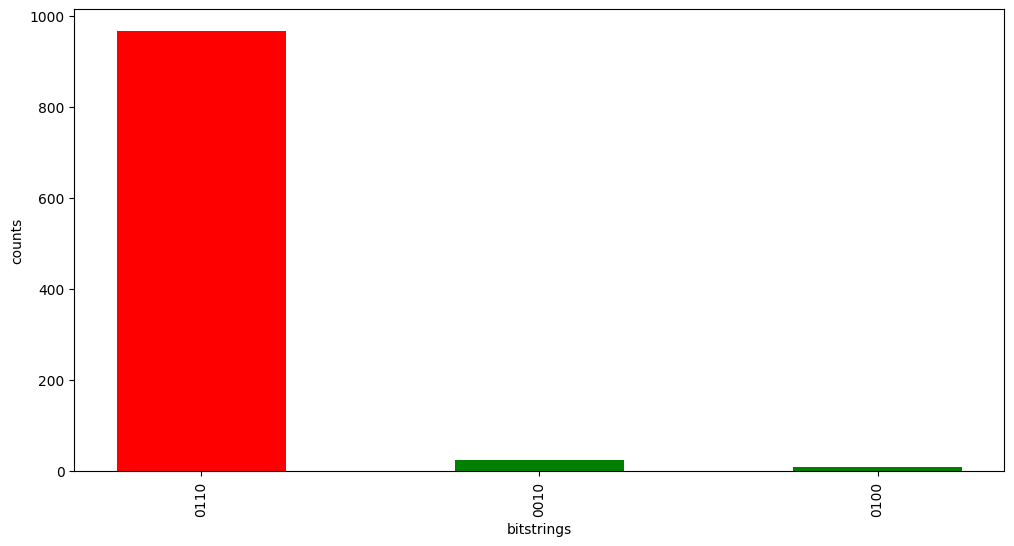

In [108]:
plot_distribution(count_dict)

We can play and change the weights of the nodes to see the change in the results.

The heuristic we are using here to define the values of Omega, delta and deltaDMM
 along time works well in this case. You will surely have to adapt these values if you change the graph (the matrix 
Q). To tune them automatically, you can use an optimization procedure to find the sequence maximizing your cost function 
. An example of an optimization procedure will be presented in next session.

This notebook can be adapted to solve a QUBO with diagonal terms, only the definition of the detuning map has to be changed.